In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from statsmodels.tsa.deterministic import DeterministicProcess
from sklearn.linear_model import LinearRegression

sns.set_theme(style="whitegrid", palette="deep")

Dropping NaN 174 values.


<Axes: xlabel='datetime'>

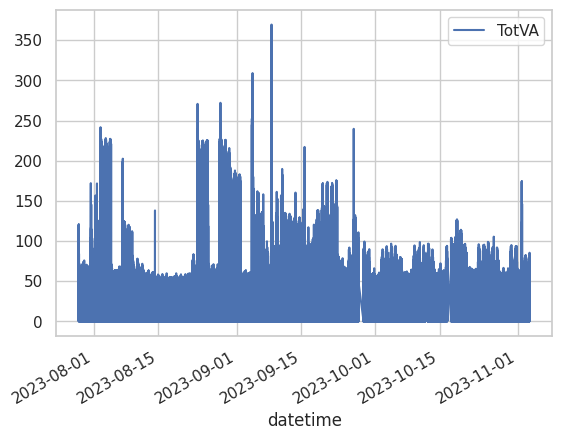

In [2]:
data_dir = Path("./data/")

df = pd.read_csv(
    data_dir / "ED18_03112023.csv",
    index_col="datetime",
    parse_dates=["datetime"],
).drop(
    [
        "_id",
        "unit_id",
        "rounded_datatime",
    ],
    axis=1,
)

# equivalent but more verbose: df = ed18_data.loc[:, "TotVA"].to_frame() 
df = df[["TotVA"]]

print(f'Dropping NaN {df.loc[:, "TotVA"].isna().sum()} values.')
df = df.dropna()

df.plot()

## Moving average plot
In the following moving average plot, we can see how, in the bounds of the data collected this far, the data is cyclic. Local trends can be observed, but globally (seasonally?) the values stay the same. This makes sense with the fact that the data comes from naturally bounded sources (i.e. electrical sensors that operate within standardized ranges).

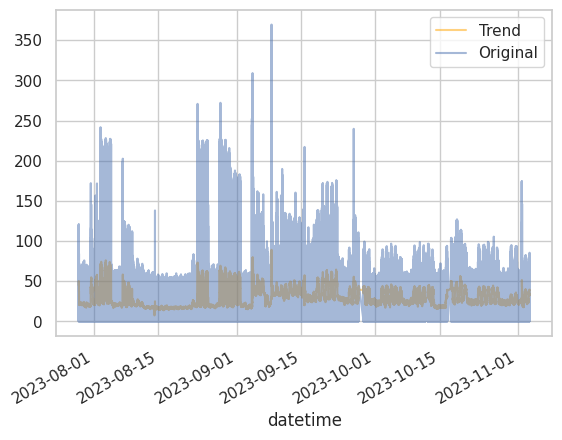

In [3]:
trend = df.rolling(
    window=30,
    center=True,
).mean()

ax = trend.plot(alpha=0.5, color="orange")
ax = df.plot(ax=ax, alpha=0.5)
ax.legend(["Trend", "Original"])

In [10]:
# target
y = df.copy()

# instantiate `DeterministicProcess` with arguments
# appropriate for a cubic trend model
dp = DeterministicProcess(
    index=df.index,
    order=2,
)

X = dp.in_sample()

# number of days to forecast
days_fore = 30

range_fore = pd.date_range(X.index[-1], X.index[-1] + pd.Timedelta(days=days_fore - 1))
X_fore = dp.out_of_sample(days_fore, range_fore)

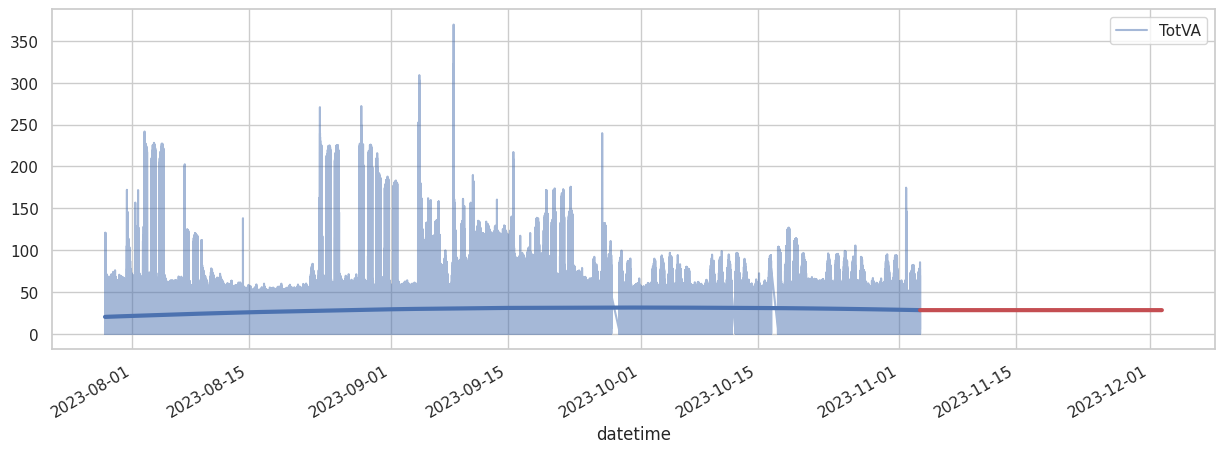

In [19]:
model = LinearRegression()
model.fit(X, y)

y_pred = pd.Series(model.predict(X).ravel(), index=X.index)
y_fore = pd.Series(model.predict(X_fore).ravel(), index=X_fore.index)

ax = y.plot(alpha=0.5, figsize=(15, 5))
ax = y_pred.plot(ax=ax, linewidth=3, color='C0')
ax = y_fore.plot(ax=ax, linewidth=3, color='C3')
ax.legend()